# Customer Churn Prediction — EDA
## Project 03 | EDA Portfolio | Prasanna Wankhede

### About the Dataset
- **Source:** IBM Sample Dataset (Kaggle)
- **File:** WA_Fn-UseC_-Telco-Customer-Churn.csv
- **Rows:** 7,043 customers
- **Columns:** 21

### What is Customer Churn?
When a customer **stops using a company's service**, it is called churn.
Telecom companies lose crores of rupees every year because of churn.
This EDA explores **why customers leave** and **what patterns exist** in the data.

### Target Column
`Churn` → Yes (left the company) / No (stayed)

### Goal
Find which factors — like contract type, monthly charges, tenure —
are most strongly related to customer churn.

## Step 1 — Import Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from scipy import stats

plt.rcParams['figure.figsize'] = (8, 5)

## Step 2 — Load Data

In [4]:
import os

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
os.makedirs('churn_images', exist_ok=True)

print("Data Loaded Successfully!")
print("Shape:", df.shape)

Data Loaded Successfully!
Shape: (7043, 21)


## Step 3 — First Look

In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### df.info() — column names, data types and null values

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### df.describe() — statistical summary of numerical columns

In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


### df.nunique() — unique values in each column

In [8]:
df.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

## Step 4 — Drop Unnecessary Columns

In [9]:
df.drop(columns=['customerID'], inplace=True)
print("Remaining columns:", df.shape[1])

Remaining columns: 20


## Step 5 — Handle Missing Values

In [10]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### Fix TotalCharges — convert to numeric and handle hidden missing values

In [11]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("Missing values in TotalCharges:", df['TotalCharges'].isnull().sum())

Missing values in TotalCharges: 11


### Fill missing TotalCharges with median

In [13]:
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
print("Missing values remaining:", df['TotalCharges'].isnull().sum())

Missing values remaining: 0


## Step 6 — Encode Categorical Columns

In [14]:
# binary columns
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})
df['Partner'] = df['Partner'].map({'Yes': 1, 'No': 0})
df['Dependents'] = df['Dependents'].map({'Yes': 1, 'No': 0})
df['PhoneService'] = df['PhoneService'].map({'Yes': 1, 'No': 0})
df['PaperlessBilling'] = df['PaperlessBilling'].map({'Yes': 1, 'No': 0})
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("Encoding done!")
df.head()

Encoding done!


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,1,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.50,0
2,1,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,1,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,0,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1


### Conclusion — Step 6
- Binary columns (gender, Partner, Dependents, PhoneService, PaperlessBilling, Churn) encoded to 0/1
- SeniorCitizen was already 0/1 — skipped
- Multi-value columns kept as text for meaningful graphs


## Step 7 — Univariate Analysis
Analyzing each column individually to understand its distribution.

### Target Column — Churn Distribution

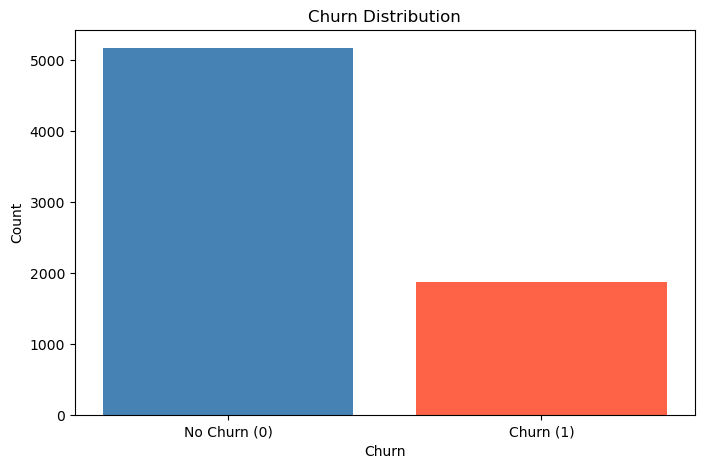

In [15]:
churn_counts = df['Churn'].value_counts()
plt.bar(['No Churn (0)', 'Churn (1)'], churn_counts.values, color=['steelblue', 'tomato'])
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.savefig('churn_images/01_churn_distribution.png')
plt.show()

### Conclusion — Churn Distribution
- Dataset is imbalanced — 74% customers stayed, 26% left
- Only 1 in 4 customers churned
- This means the company is retaining most customers
- But the 26% who left represent significant revenue loss

### Gender Distribution

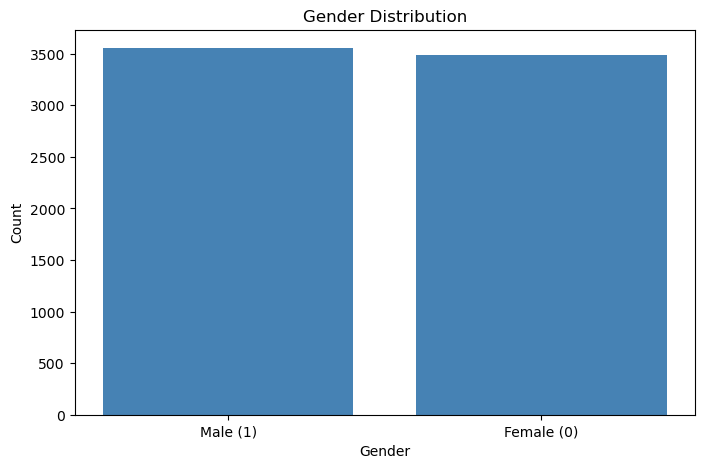

In [16]:
gender_counts = df['gender'].value_counts()
plt.bar(['Male (1)', 'Female (0)'], gender_counts.values, color='steelblue')
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.savefig('churn_images/02_gender_distribution.png')
plt.show()

### Conclusion — Gender Distribution
- Dataset has almost equal male and female customers
- Male: ~3560 (50.5%) | Female: ~3490 (49.5%)
- Gender is evenly distributed — no dominance of either group

### SeniorCitizen Distribution

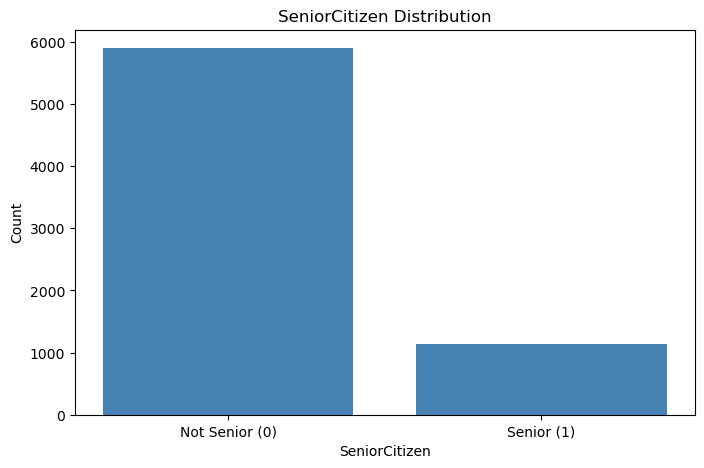

In [17]:
senior_counts = df['SeniorCitizen'].value_counts()
plt.bar(['Not Senior (0)', 'Senior (1)'], senior_counts.values, color='steelblue')
plt.title('SeniorCitizen Distribution')
plt.xlabel('SeniorCitizen')
plt.ylabel('Count')
plt.savefig('churn_images/03_seniorcitizen_distribution.png')
plt.show()

### Conclusion — SeniorCitizen Distribution
- Most customers are not senior citizens (~84%)
- Only ~16% customers are senior citizens
- Heavily imbalanced — very few senior customers in the dataset

### Partner Distribution

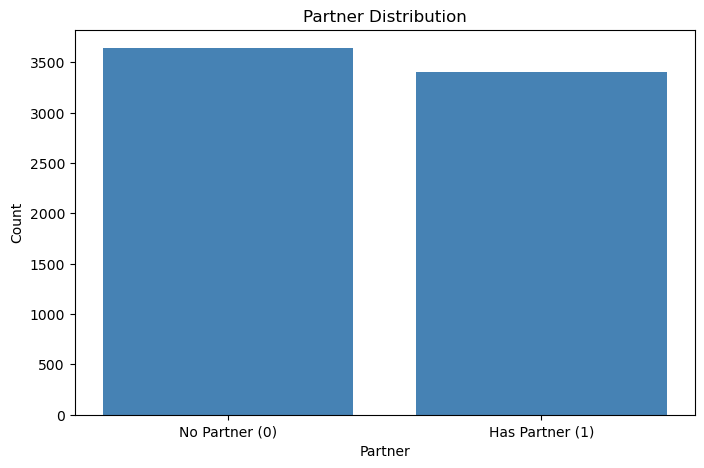

In [19]:
partner_counts = df['Partner'].value_counts()
plt.bar(['No Partner (0)', 'Has Partner (1)'], partner_counts.values, color='steelblue')
plt.title('Partner Distribution')
plt.xlabel('Partner')
plt.ylabel('Count')
plt.savefig('churn_images/04_partner_distribution.png')
plt.show()

### Conclusion — Partner Distribution
- Almost equal split between customers with and without partners
- No Partner: ~52% | Has Partner: ~48%
- Partner distribution is fairly balanced in the dataset

### Dependents Distribution

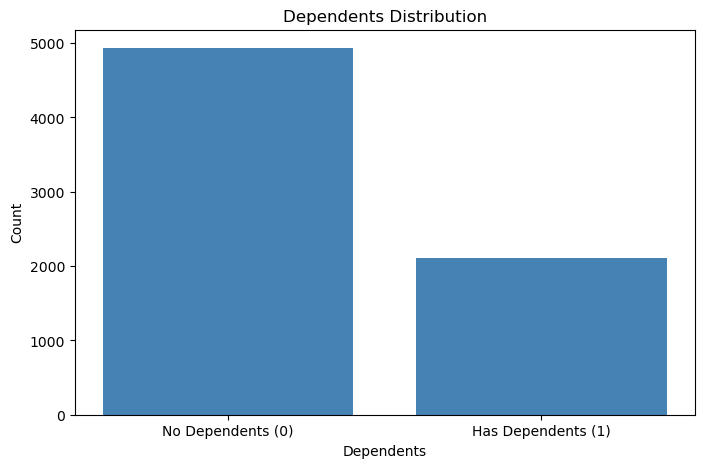

In [20]:
dependents_counts = df['Dependents'].value_counts()
plt.bar(['No Dependents (0)', 'Has Dependents (1)'], dependents_counts.values, color='steelblue')
plt.title('Dependents Distribution')
plt.xlabel('Dependents')
plt.ylabel('Count')
plt.savefig('churn_images/05_dependents_distribution.png')
plt.show()

### Conclusion — Dependents Distribution
- Most customers have no dependents (~70%)
- Only ~30% customers have dependents
- Imbalanced distribution — effect on churn will be checked in bivariate analysis

### PhoneService Distribution

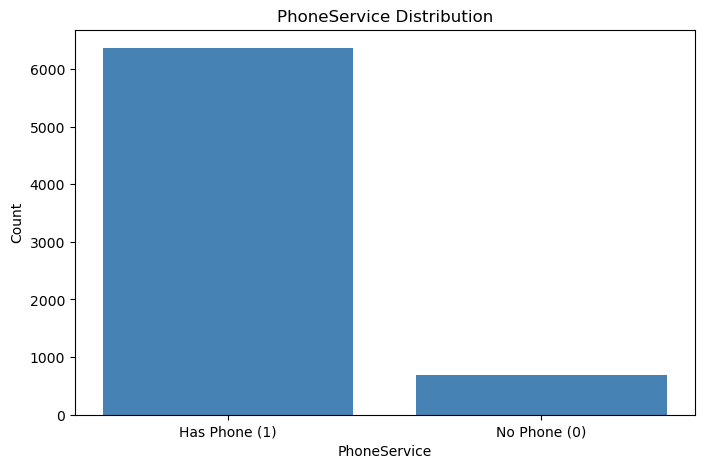

In [21]:
phone_counts = df['PhoneService'].value_counts()
plt.bar(['Has Phone (1)', 'No Phone (0)'], phone_counts.values, color='steelblue')
plt.title('PhoneService Distribution')
plt.xlabel('PhoneService')
plt.ylabel('Count')
plt.savefig('churn_images/06_phoneservice_distribution.png')
plt.show()

### Conclusion — PhoneService Distribution
- Majority of customers (~90%) have phone service
- Only ~10% customers have no phone service
- Heavily imbalanced — most customers use phone service

### MultipleLines Distribution

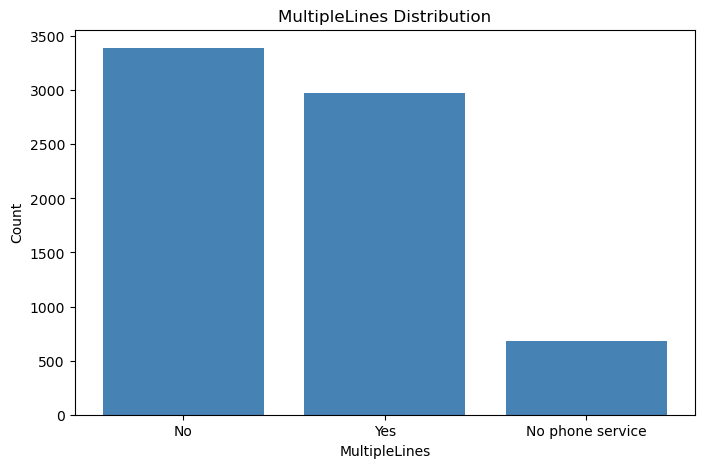

In [22]:
multiple_counts = df['MultipleLines'].value_counts()
plt.bar(multiple_counts.index, multiple_counts.values, color='steelblue')
plt.title('MultipleLines Distribution')
plt.xlabel('MultipleLines')
plt.ylabel('Count')
plt.savefig('churn_images/07_multiplelines_distribution.png')
plt.show()

### Conclusion — MultipleLines Distribution
- Customers are almost equally split between single and multiple lines
- No: ~48% | Yes: ~43% | No Phone Service: ~9%
- No phone service group matches PhoneService distribution

### InternetService Distribution

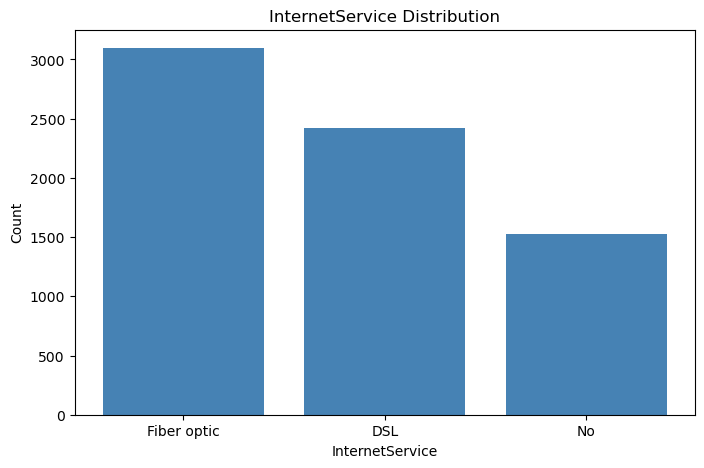

In [23]:
internet_counts = df['InternetService'].value_counts()
plt.bar(internet_counts.index, internet_counts.values, color='steelblue')
plt.title('InternetService Distribution')
plt.xlabel('InternetService')
plt.ylabel('Count')
plt.savefig('churn_images/08_internetservice_distribution.png')
plt.show()

### Conclusion — InternetService Distribution
- Fiber optic is the most popular internet service (~44%)
- DSL is second (~34%)
- ~22% customers have no internet service
- Fiber optic customers pay more — could be linked to higher churn

### Contract Distribution

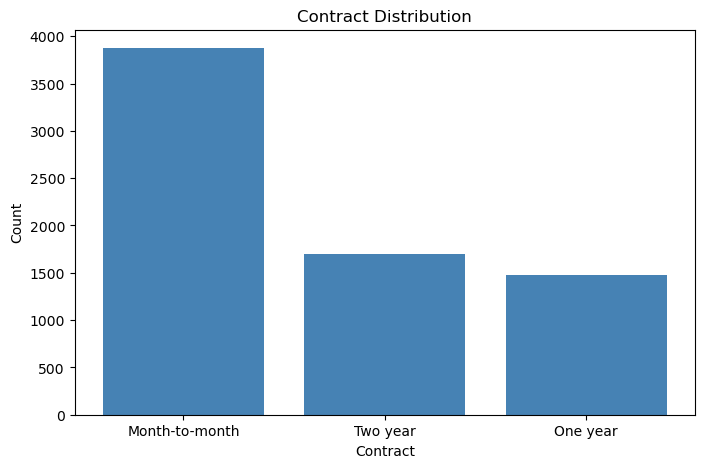

In [24]:
contract_counts = df['Contract'].value_counts()
plt.bar(contract_counts.index, contract_counts.values, color='steelblue')
plt.title('Contract Distribution')
plt.xlabel('Contract')
plt.ylabel('Count')
plt.savefig('churn_images/09_contract_distribution.png')
plt.show()

### Conclusion — Contract Distribution
- More than half the customers (~55%) are on month-to-month contract
- Two year: ~24% | One year: ~21%
- Month-to-month customers have no commitment — highest churn risk
- Contract type is expected to be a strong predictor of churn

### PaymentMethod Distribution

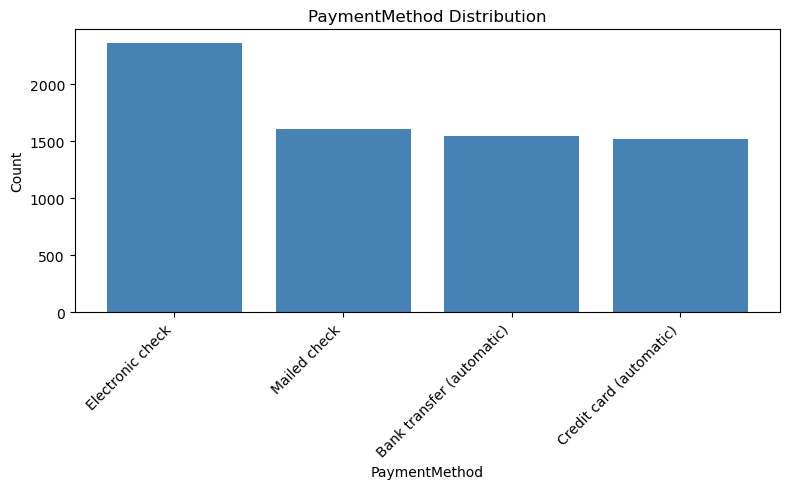

In [25]:
payment_counts = df['PaymentMethod'].value_counts()
plt.bar(payment_counts.index, payment_counts.values, color='steelblue')
plt.title('PaymentMethod Distribution')
plt.xlabel('PaymentMethod')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('churn_images/10_paymentmethod_distribution.png')
plt.show()

### Conclusion — PaymentMethod Distribution
- Electronic check is the most popular payment method (~33%)
- Other 3 methods are almost equally distributed (~22% each)
- Electronic check is manual — could be linked to higher churn
- Automatic payment customers may be more loyal

### Tenure Distribution — Histogram and Boxplot

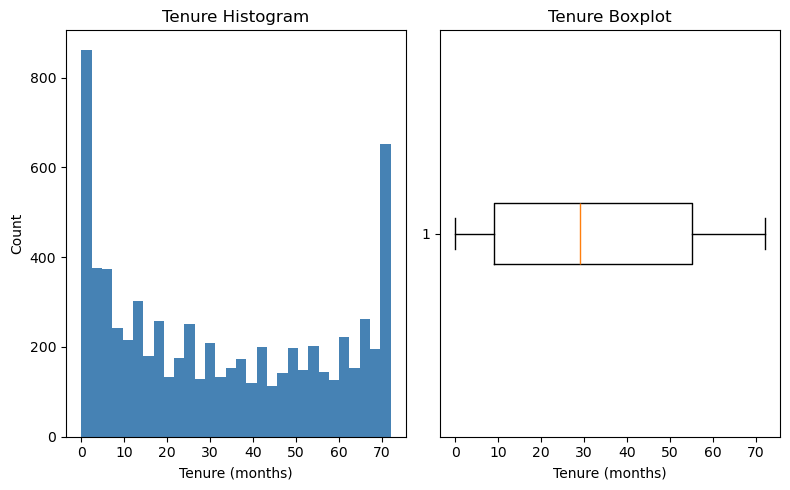

In [26]:
fig, axes = plt.subplots(1, 2)
axes[0].hist(df['tenure'], bins=30, color='steelblue')
axes[0].set_title('Tenure Histogram')
axes[0].set_xlabel('Tenure (months)')
axes[0].set_ylabel('Count')

axes[1].boxplot(df['tenure'], vert=False)
axes[1].set_title('Tenure Boxplot')
axes[1].set_xlabel('Tenure (months)')

plt.tight_layout()
plt.savefig('churn_images/11_tenure_distribution.png')
plt.show()

### Conclusion — Tenure Distribution
- Bimodal distribution — two peaks at month 0-1 and month 70-72
- Two clear customer groups — new customers and very loyal customers
- No outliers found in boxplot
- Median tenure is ~30 months
- New customers are at highest risk of churn

### MonthlyCharges Distribution — Histogram and Boxplot

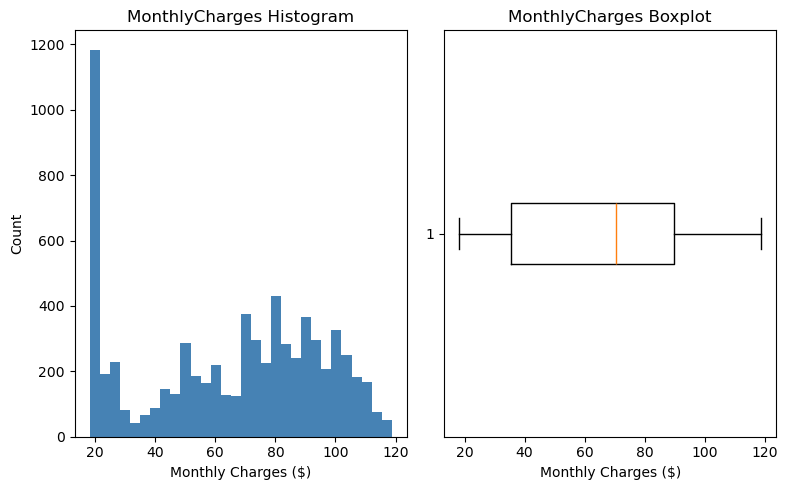

In [27]:
fig, axes = plt.subplots(1, 2)
axes[0].hist(df['MonthlyCharges'], bins=30, color='steelblue')
axes[0].set_title('MonthlyCharges Histogram')
axes[0].set_xlabel('Monthly Charges ($)')
axes[0].set_ylabel('Count')

axes[1].boxplot(df['MonthlyCharges'], vert=False)
axes[1].set_title('MonthlyCharges Boxplot')
axes[1].set_xlabel('Monthly Charges ($)')

plt.tight_layout()
plt.savefig('churn_images/12_monthlycharges_distribution.png')
plt.show()

### Conclusion — MonthlyCharges Distribution
- Right skewed distribution — many customers pay low charges (~$20)
- Median monthly charge is ~$70
- No outliers found in boxplot
- High charges could be linked to higher churn — customers may find it too expensive

### TotalCharges Distribution — Histogram and Boxplot

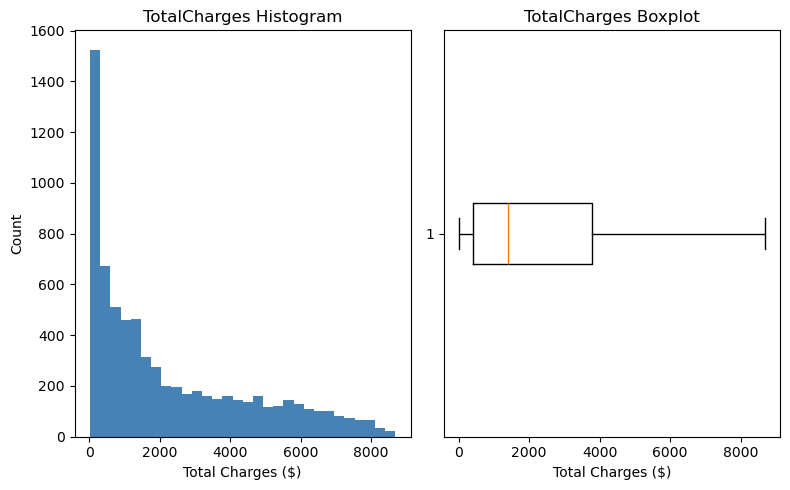

In [28]:
fig, axes = plt.subplots(1, 2)
axes[0].hist(df['TotalCharges'], bins=30, color='steelblue')
axes[0].set_title('TotalCharges Histogram')
axes[0].set_xlabel('Total Charges ($)')
axes[0].set_ylabel('Count')

axes[1].boxplot(df['TotalCharges'], vert=False)
axes[1].set_title('TotalCharges Boxplot')
axes[1].set_xlabel('Total Charges ($)')

plt.tight_layout()
plt.savefig('churn_images/13_totalcharges_distribution.png')
plt.show()

### Conclusion — TotalCharges Distribution
- Right skewed distribution — most customers have low total charges
- Majority of customers are relatively new (low tenure = low total charges)
- No outliers found in boxplot
- Median total charge is ~$1500
- High total charges indicate loyal long term customers

## Step 8 — Bivariate Analysis
Analyzing relationship between each column and the target column Churn.
- Categorical vs Churn → Chi-square test
- Numerical vs Churn → ANOVA test
- p < 0.05 → Dependent (significant)
- p > 0.05 → Independent (not significant)

### Chi-square Test — Gender vs Churn

In [29]:
ct = pd.crosstab(df['gender'], df['Churn'])
chi2, p, dof, expected = chi2_contingency(ct)
print("Chi-square value:", chi2)
print("p-value:", p)
print("Dependent (significant)" if p < 0.05 else "Independent (not significant)")

Chi-square value: 0.4840828822091383
p-value: 0.48657873605618596
Independent (not significant)


### Conclusion — Gender vs Churn
- Chi-square p-value = 0.487 (p > 0.05)
- Gender is Independent of Churn
- Male and female customers churn at equal rates
- Gender is NOT a useful predictor of churn

### Chi-square Test — SeniorCitizen vs Churn

In [30]:
ct = pd.crosstab(df['SeniorCitizen'], df['Churn'])
chi2, p, dof, expected = chi2_contingency(ct)
print("Chi-square value:", chi2)
print("p-value:", p)
print("Dependent (significant)" if p < 0.05 else "Independent (not significant)")

Chi-square value: 159.42630036838742
p-value: 1.510066805092378e-36
Dependent (significant)


### Conclusion — SeniorCitizen vs Churn
- Chi-square p-value = 1.51e-36 (p < 0.05)
- SeniorCitizen is Dependent on Churn
- Senior citizens are significantly more likely to churn
- Age is an important predictor of churn

### Chi-square Test — Partner vs Churn

In [31]:
ct = pd.crosstab(df['Partner'], df['Churn'])
chi2, p, dof, expected = chi2_contingency(ct)
print("Chi-square value:", chi2)
print("p-value:", p)
print("Dependent (significant)" if p < 0.05 else "Independent (not significant)")

Chi-square value: 158.7333820309922
p-value: 2.1399113440759935e-36
Dependent (significant)


### Conclusion — Partner vs Churn
- Chi-square p-value = 2.14e-36 (p < 0.05)
- Partner is Dependent on Churn
- Customers without a partner are more likely to churn
- Having a partner increases customer loyalty

### Chi-square Test — Dependents vs Churn

In [32]:
ct = pd.crosstab(df['Dependents'], df['Churn'])
chi2, p, dof, expected = chi2_contingency(ct)
print("Chi-square value:", chi2)
print("p-value:", p)
print("Dependent (significant)" if p < 0.05 else "Independent (not significant)")

Chi-square value: 189.12924940423474
p-value: 4.9249216612154196e-43
Dependent (significant)


### Conclusion — Dependents vs Churn
- Chi-square p-value = 4.92e-43 (p < 0.05)
- Dependents is Dependent on Churn
- Customers with dependents are significantly less likely to churn
- Family responsibility increases customer loyalty

### Chi-square Test — PhoneService vs Churn

In [33]:
ct = pd.crosstab(df['PhoneService'], df['Churn'])
chi2, p, dof, expected = chi2_contingency(ct)
print("Chi-square value:", chi2)
print("p-value:", p)
print("Dependent (significant)" if p < 0.05 else "Independent (not significant)")

Chi-square value: 0.9150329892546948
p-value: 0.3387825358066928
Independent (not significant)


### Conclusion — PhoneService vs Churn
- Chi-square p-value = 0.339 (p > 0.05)
- PhoneService is Independent of Churn
- Having phone service does not influence churn decision
- Almost all customers have phone service — not a useful predictor

### Chi-square Test — Contract vs Churn

In [34]:
ct = pd.crosstab(df['Contract'], df['Churn'])
chi2, p, dof, expected = chi2_contingency(ct)
print("Chi-square value:", chi2)
print("p-value:", p)
print("Dependent (significant)" if p < 0.05 else "Independent (not significant)")

Chi-square value: 1184.5965720837926
p-value: 5.863038300673391e-258
Dependent (significant)


### Conclusion — Contract vs Churn
- Chi-square p-value = 5.86e-258 (p < 0.05)
- Contract is Dependent on Churn
- Strongest predictor of churn found so far!
- Month-to-month customers churn the most
- Long term contract customers are highly loyal
- Telecom company should push customers towards longer contracts

### Chi-square Test — PaperlessBilling vs Churn

In [35]:
ct = pd.crosstab(df['PaperlessBilling'], df['Churn'])
chi2, p, dof, expected = chi2_contingency(ct)
print("Chi-square value:", chi2)
print("p-value:", p)
print("Dependent (significant)" if p < 0.05 else "Independent (not significant)")

Chi-square value: 258.27764906707307
p-value: 4.073354668665985e-58
Dependent (significant)


### Conclusion — PaperlessBilling vs Churn
- Chi-square p-value = 4.07e-58 (p < 0.05)
- PaperlessBilling is Dependent on Churn
- Customers with paperless billing churn more
- Tech savvy customers compare plans easily and switch more often

## Step 8 — Bivariate Analysis | MultipleLines vs Churn (Chi-square)

In [37]:
ct = pd.crosstab(df['MultipleLines'], df['Churn'])
chi2, p, dof, expected = chi2_contingency(ct)
print(f"Chi-square: {chi2:.4f}")
print(f"p-value: {p}")
print("Dependent ✅" if p < 0.05 else "Independent ❌")

Chi-square: 11.3304
p-value: 0.0034643829548773003
Dependent ✅


### Conclusion
MultipleLines is dependent on Churn (p = 0.0034).
Customers with multiple lines behave differently in terms of churn.

## Step 8 — Bivariate Analysis | InternetService vs Churn (Chi-square)

In [38]:
ct = pd.crosstab(df['InternetService'], df['Churn'])
chi2, p, dof, expected = chi2_contingency(ct)
print(f"Chi-square: {chi2:.4f}")
print(f"p-value: {p}")
print("Dependent ✅" if p < 0.05 else "Independent ❌")

Chi-square: 732.3096
p-value: 9.571788222840544e-160
Dependent ✅


### Conclusion
InternetService is strongly dependent on Churn (p = 9.57e-160).
Internet service type is one of the strongest predictors of churn.

## Step 8 — Bivariate Analysis | OnlineSecurity vs Churn (Chi-square)

In [39]:
ct = pd.crosstab(df['OnlineSecurity'], df['Churn'])
chi2, p, dof, expected = chi2_contingency(ct)
print(f"Chi-square: {chi2:.4f}")
print(f"p-value: {p}")
print("Dependent ✅" if p < 0.05 else "Independent ❌")

Chi-square: 849.9990
p-value: 2.661149635176552e-185
Dependent ✅


### Conclusion
OnlineSecurity is strongly dependent on Churn (p = 2.66e-185).
Customers without online security are much more likely to churn.

## Step 8 — Bivariate Analysis | OnlineBackup vs Churn (Chi-square)

In [40]:
ct = pd.crosstab(df['OnlineBackup'], df['Churn'])
chi2, p, dof, expected = chi2_contingency(ct)
print(f"Chi-curve: {chi2:.4f}")
print(f"p-value: {p}")
print("Dependent ✅" if p < 0.05 else "Independent ❌")

Chi-curve: 601.8128
p-value: 2.0797592160864276e-131
Dependent ✅


### Conclusion
OnlineBackup is strongly dependent on Churn (p = 2.08e-131).
Customers without online backup are more likely to churn.

## Step 8 — Bivariate Analysis | DeviceProtection vs Churn (Chi-square)

In [41]:
ct = pd.crosstab(df['DeviceProtection'], df['Churn'])
chi2, p, dof, expected = chi2_contingency(ct)
print(f"Chi-square: {chi2:.4f}")
print(f"p-value: {p}")
print("Dependent ✅" if p < 0.05 else "Independent ❌")

Chi-square: 558.4194
p-value: 5.505219496457244e-122
Dependent ✅


### Conclusion
DeviceProtection is strongly dependent on Churn (p = 5.51e-122).
Customers without device protection are more likely to churn.

## Step 8 — Bivariate Analysis | TechSupport vs Churn (Chi-square)

In [43]:
ct = pd.crosstab(df['TechSupport'], df['Churn'])
chi2, p, dof, expected = chi2_contingency(ct)
print(f"Chi-square: {chi2:.4f}")
print(f"p-value: {p}")
print("Dependent ✅" if p < 0.05 else "Independent ❌")

Chi-square: 828.1971
p-value: 1.4430840279998987e-180
Dependent ✅


### Conclusion
TechSupport is strongly dependent on Churn (p = 1.44e-180).
Customers without tech support are much more likely to churn.

## Step 8 — Bivariate Analysis | StreamingTV vs Churn (Chi-square)

In [44]:
ct = pd.crosstab(df['StreamingTV'], df['Churn'])
chi2, p, dof, expected = chi2_contingency(ct)
print(f"Chi-square: {chi2:.4f}")
print(f"p-value: {p}")
print("Dependent ✅" if p < 0.05 else "Independent ❌")

Chi-square: 374.2039
p-value: 5.528994485739183e-82
Dependent ✅


### Conclusion
StreamingTV is dependent on Churn (p = 5.53e-82).
Customers with streaming TV services show different churn behavior.

## Step 8 — Bivariate Analysis | StreamingMovies vs Churn (Chi-square)

In [45]:
ct = pd.crosstab(df['StreamingMovies'], df['Churn'])
chi2, p, dof, expected = chi2_contingency(ct)
print(f"Chi-square: {chi2:.4f}")
print(f"p-value: {p}")
print("Dependent ✅" if p < 0.05 else "Independent ❌")

Chi-square: 375.6615
p-value: 2.667756755723681e-82
Dependent ✅


### Conclusion
StreamingMovies is dependent on Churn (p = 2.67e-82).
Similar to StreamingTV, movie streaming behavior is linked to churn.

## Step 8 — Bivariate Analysis | PaymentMethod vs Churn (Chi-square)

In [46]:
ct = pd.crosstab(df['PaymentMethod'], df['Churn'])
chi2, p, dof, expected = chi2_contingency(ct)
print(f"Chi-square: {chi2:.4f}")
print(f"p-value: {p}")
print("Dependent ✅" if p < 0.05 else "Independent ❌")

Chi-square: 648.1423
p-value: 3.6823546520097993e-140
Dependent ✅


### Conclusion
PaymentMethod is strongly dependent on Churn (p = 3.68e-140).
Customers using electronic check are more likely to churn than automatic payment users.

## Step 8 — Bivariate Analysis | tenure vs Churn (ANOVA)

In [47]:
churn_yes = df[df['Churn'] == 1]['tenure']
churn_no = df[df['Churn'] == 0]['tenure']
f, p = stats.f_oneway(churn_yes, churn_no)
print(f"F-statistic: {f:.4f}")
print(f"p-value: {p}")
print("Dependent ✅" if p < 0.05 else "Independent ❌")

F-statistic: 997.2680
p-value: 7.999057960610892e-205
Dependent ✅


### Conclusion
Tenure is strongly dependent on Churn (p = 7.99e-205).
New customers churn much more than long-term customers.

## Step 8 — Bivariate Analysis | MonthlyCharges vs Churn (ANOVA)

In [48]:
churn_yes = df[df['Churn'] == 1]['MonthlyCharges']
churn_no = df[df['Churn'] == 0]['MonthlyCharges']
f, p = stats.f_oneway(churn_yes, churn_no)
print(f"F-statistic: {f:.4f}")
print(f"p-value: {p}")
print("Dependent ✅" if p < 0.05 else "Independent ❌")

F-statistic: 273.4637
p-value: 2.7066456068950115e-60
Dependent ✅


### Conclusion
MonthlyCharges is strongly dependent on Churn (p = 2.71e-60).
Customers with higher monthly charges are more likely to churn.

## Step 8 — Bivariate Analysis | TotalCharges vs Churn (ANOVA)

In [50]:
churn_yes = df[df['Churn'] == 1]['TotalCharges']
churn_no = df[df['Churn'] == 0]['TotalCharges']
f, p = stats.f_oneway(churn_yes, churn_no)
print(f"F-statistic: {f:.4f}")
print(f"p-value: {p}")
print("Dependent ✅" if p < 0.05 else "Independent ❌")

F-statistic: 290.4398
p-value: 7.508609056724576e-64
Dependent ✅


### Conclusion
TotalCharges is strongly dependent on Churn (p = 7.51e-64).
Customers with lower total charges (newer customers) are more likely to churn.

## Step 9 — Multivariate Analysis | Correlation Matrix

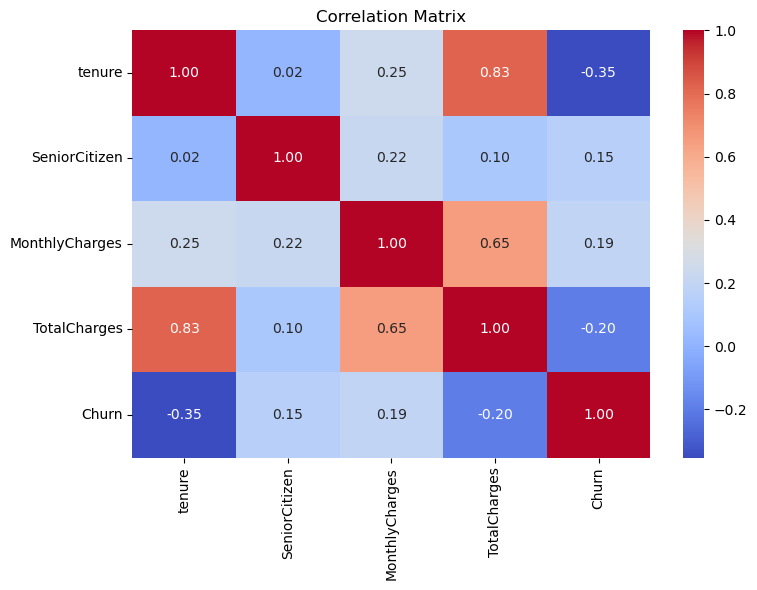

In [51]:
num_cols = ['tenure', 'SeniorCitizen', 'MonthlyCharges', 'TotalCharges', 'Churn']
corr = df[num_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.savefig('churn_images/14_correlation_matrix.png')
plt.show()

### Conclusion
tenure has the strongest negative correlation with Churn (-0.35).
Longer staying customers are less likely to churn.
MonthlyCharges has a positive correlation (0.19) — higher bills increase churn risk.
tenure and TotalCharges are highly correlated (0.83) — multicollinearity exists.

## Step 9 — Multivariate Analysis | FacetGrid Scatter Plot

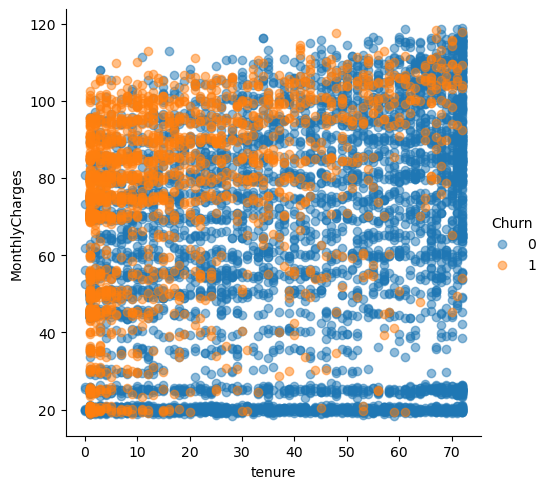

In [52]:
g = sns.FacetGrid(df, hue='Churn', height=5)
g.map(plt.scatter, 'tenure', 'MonthlyCharges', alpha=0.5)
g.add_legend()
plt.savefig('churn_images/15_scatter_tenure_monthlycharges.png')
plt.show()

### Conclusion
New customers with high monthly charges churn the most (orange dots top-left).
Long tenure customers rarely churn regardless of monthly charges.
Low monthly charge customers tend to stay with the company.

## Step 9 — Multivariate Analysis | FacetGrid Scatter Plot 2

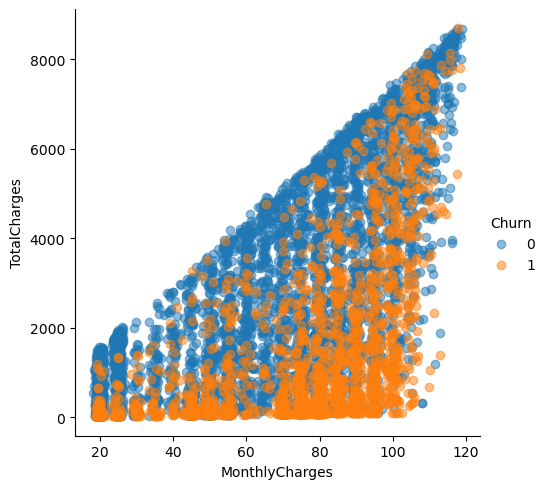

In [53]:
g = sns.FacetGrid(df, hue='Churn', height=5)
g.map(plt.scatter, 'MonthlyCharges', 'TotalCharges', alpha=0.5)
g.add_legend()
plt.savefig('churn_images/16_scatter_monthlycharges_totalcharges.png')
plt.show()

### Conclusion
Churned customers (orange) have low TotalCharges but high MonthlyCharges.
This confirms new customers paying high monthly bills are most likely to churn.
Loyal customers (blue) accumulate high TotalCharges over time.

## Step 10 — Conclusions & Key Message

### Key Findings

**Independent Columns (No effect on Churn):**
- gender → p = 0.487
- PhoneService → p = 0.339

**Strongest Predictors of Churn:**
- Contract → p = 5.86e-258 (STRONGEST 👑)
- OnlineSecurity → p = 2.66e-185
- TechSupport → p = 1.44e-180
- InternetService → p = 9.57e-160
- tenure → p = 7.99e-205

**Most Likely Customer to Churn:**
- New customer (low tenure)
- Month-to-month contract
- Fiber optic internet user
- No online security or tech support
- Pays by electronic check
- No partner or dependents
- High monthly charges

**Key Message:**
Telecom company should focus on new customers with month-to-month
contracts and high monthly charges — they are at highest risk of churning.
Offering long-term contracts and security services can reduce churn significantly.